# 07 - Curse of Dimensionality

Mehr Merkmale bedeuten nicht automatisch mehr Information. Dieses
Notebook überlädt ein k-Nearest-Neighbors-Modell schrittweise mit:

1. 100 ALA-Merkmalen,
2. 168 Phasendynamik-Merkmalen,
3. 360 Rohsignalwerten,
4. 360 Ableitungswerten,
5. 256 Spektralmerkmalen,
6. 1.000 explizit irrelevanten Kontrollmerkmalen.

k-NN ist dafür ein anschauliches Modell: Wenn jede Dimension gleich
skaliert eingeht, werden euklidische Abstände in hoher Dimension immer
ähnlicher. Der Begriff „nächster Nachbar“ verliert an Aussagekraft.

## Software, Distanzmodell und Parameter

**Eingaben**

- GAS wählt das Zielgas.
- N_ALA_SEGMENTS steuert die ALA-Basis.
- N_NOISE_FEATURES legt die Anzahl eindeutig irrelevanter Kontrollmerkmale fest.
- RANDOM_STATE_DEMO reproduziert dieses Kontrollrauschen.

NumPy erzeugt Rohwertblöcke, erste Differenzen und mit numpy.fft.rfft ein
Frequenzspektrum. sklearn.neighbors.KNeighborsRegressor sagt den Zielwert aus
den k ähnlichsten Trainingszeilen vorher. Die Option weights = "distance"
gewichtet nahe Nachbarn stärker; p = 2 entspricht euklidischer Distanz.

k wird in diesem Notebook einmal auf der kompakten ALA-Baseline aus
3, 5, 7, 11, 21 und 31 gewählt und danach für alle Dimensionen festgehalten.
Kleines k ist flexibel und rauschempfindlich, großes k glättet stärker.

Vor der Distanzberechnung wird jede Spalte mit Trainingsmittelwert und
Trainingsstandardabweichung z-standardisiert. Ohne Skalierung würden Merkmale
mit großen Zahlenwerten dominieren. scipy.spatial.distance bietet weitere
Distanzfunktionen; scikit-learn übernimmt hier Fit und Vorhersage direkt.

Die 1.000 Rauschmerkmale sind ein kontrolliertes Experiment. Sie dürfen nicht
als reale Sensorinformation interpretiert werden.

In [1]:
GAS = "hydrogen"
N_ALA_SEGMENTS = 50
N_NOISE_FEATURES = 1000
RANDOM_STATE_DEMO = 73

In [2]:
from pathlib import Path
from html import escape
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.neighbors import KNeighborsRegressor

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Neuaufbau"
sys.path.insert(0, str(HERE.resolve()))

from dataset_pipeline import *
from physics_features import (
    extract_ala_features,
    extract_phase_features,
    learn_ala_breakpoints,
)

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unbekanntes Gas: {GAS}")
plt.style.use("seaborn-v0_8-whitegrid")
splits = prepare_splits("stored")

def show_table(rows, columns, digits=3):
    def formatted(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.{digits}f}"
        return str(value)
    header = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body = "".join(
        "<tr>" + "".join(
            f"<td>{escape(formatted(row[column]))}</td>" for column in columns
        ) + "</tr>" for row in rows
    )
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))

## 1. Merkmalsblöcke erzeugen

ALA-Grenzen werden nur am Trainingsmedian gelernt. Rohsignal und
Ableitung werden auf jedes vierte Sample reduziert. Das Spektrum nutzt
die ersten 256 Beträge der reellen FFT ohne Gleichanteil.

Die Kontrollmerkmale sind reproduzierbares Gaußrauschen und enthalten
absichtlich keinerlei Zielinformation. Sie machen sichtbar, was
geschieht, wenn unkritisch immer weitere Messgrößen aufgenommen werden.

In [3]:
train_reference = np.median(splits["train"]["X"][:, 0, :], axis=0)
ala_breakpoints = learn_ala_breakpoints(
    train_reference, n_segments=N_ALA_SEGMENTS
)

blocks = {split: {} for split in SPLIT_NAMES}
for split_number, split in enumerate(SPLIT_NAMES):
    raw = splits[split]["X"][:, 0, :].astype(float)
    ala, ala_names = extract_ala_features(
        splits[split]["X"], ala_breakpoints
    )
    phase, phase_names = extract_phase_features(splits[split]["X"])
    raw_sparse = raw[:, ::4]
    derivative_sparse = np.diff(raw, axis=1)[:, ::4]
    spectrum = np.abs(np.fft.rfft(raw - raw.mean(axis=1, keepdims=True), axis=1))
    spectrum = np.log1p(spectrum[:, 1:257])
    rng = np.random.default_rng(RANDOM_STATE_DEMO + split_number)
    noise = rng.normal(size=(len(raw), N_NOISE_FEATURES))

    blocks[split] = {
        "ALA": ala,
        "Phasendynamik": phase,
        "Rohsignal / 4": raw_sparse,
        "Ableitung / 4": derivative_sparse,
        "Spektrum": spectrum,
        "Irrelevante Kontrolle": noise,
    }

block_rows = [
    {"Merkmalsblock": name, "Anzahl": values.shape[1]}
    for name, values in blocks["train"].items()
]
show_table(block_rows, ["Merkmalsblock", "Anzahl"], digits=0)

Merkmalsblock,Anzahl
ALA,100
Phasendynamik,168
Rohsignal / 4,360
Ableitung / 4,360
Spektrum,256
Irrelevante Kontrolle,1000


## 2. k nur auf der ALA-Baseline wählen

In [4]:
def standardize(feature_dict):
    mean = feature_dict["train"].mean(axis=0)
    scale = feature_dict["train"].std(axis=0)
    scale[scale < 1e-12] = 1.0
    return {
        split: (feature_dict[split] - mean) / scale
        for split in SPLIT_NAMES
    }

ala_only = {
    split: blocks[split]["ALA"] for split in SPLIT_NAMES
}
ala_scaled = standardize(ala_only)
y_train = splits["train"]["targets"][GAS].astype(float)
y_val = splits["val"]["targets"][GAS].astype(float)

def r2(y_true, prediction):
    residual = np.asarray(y_true) - np.asarray(prediction)
    return 1 - np.sum(residual ** 2) / np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

k_trials = []
for k in (3, 5, 7, 11, 21, 31):
    candidate = KNeighborsRegressor(n_neighbors=k, weights="distance")
    candidate.fit(ala_scaled["train"], y_train)
    score = r2(y_val, candidate.predict(ala_scaled["val"]))
    k_trials.append({"k": k, "R2 Validation": score})
BEST_K = max(k_trials, key=lambda row: row["R2 Validation"])["k"]
show_table(k_trials, ["k", "R2 Validation"])
print("Fest gewähltes k für alle folgenden Dimensionen:", BEST_K)

k,R2 Validation
3,0.712
5,0.737
7,0.751
11,0.754
21,0.752
31,0.737


Fest gewähltes k für alle folgenden Dimensionen: 11


## 3. Das Modell schrittweise mit Merkmalen überladen

In [5]:
stage_definitions = [
    ("ALA", ["ALA"]),
    ("+ Phasendynamik", ["ALA", "Phasendynamik"]),
    ("+ Rohsignal", ["ALA", "Phasendynamik", "Rohsignal / 4"]),
    ("+ Ableitung", [
        "ALA", "Phasendynamik", "Rohsignal / 4", "Ableitung / 4"
    ]),
    ("+ Spektrum", [
        "ALA", "Phasendynamik", "Rohsignal / 4",
        "Ableitung / 4", "Spektrum"
    ]),
    ("+ 1000 irrelevante", list(blocks["train"])),
]

def regression_metrics(y_true, prediction):
    residual = np.asarray(y_true) - np.asarray(prediction)
    mse = float(np.mean(residual ** 2))
    return {
        "R2": r2(y_true, prediction),
        "RMSE": np.sqrt(mse),
        "MAE": float(np.mean(np.abs(residual))),
    }

stage_results = []
stage_models = {}
stage_scaled = {}
for stage_name, block_names in stage_definitions:
    feature_dict = {
        split: np.column_stack([
            blocks[split][block_name] for block_name in block_names
        ])
        for split in SPLIT_NAMES
    }
    scaled = standardize(feature_dict)
    model = KNeighborsRegressor(
        n_neighbors=BEST_K,
        weights="distance",
        metric="minkowski",
        p=2,
    )
    model.fit(scaled["train"], y_train)
    stage_models[stage_name] = model
    stage_scaled[stage_name] = scaled
    for split in SPLIT_NAMES:
        prediction = model.predict(scaled[split])
        stage_results.append({
            "Stufe": stage_name,
            "Merkmale": scaled["train"].shape[1],
            "Split": split,
            **regression_metrics(
                splits[split]["targets"][GAS].astype(float), prediction
            ),
        })

show_table(
    stage_results,
    ["Stufe", "Merkmale", "Split", "R2", "RMSE", "MAE"],
)

Stufe,Merkmale,Split,R2,RMSE,MAE
ALA,100,train,1.000,0.000,0.000
ALA,100,val,0.754,225.684,177.806
ALA,100,test,0.738,237.534,191.270
ALA,100,test_extra,-0.072,477.483,388.887
+ Phasendynamik,268,train,1.000,0.000,0.000
+ Phasendynamik,268,val,0.739,232.553,187.178
+ Phasendynamik,268,test,0.711,249.319,199.064
+ Phasendynamik,268,test_extra,-0.110,485.919,395.459
+ Rohsignal,628,train,1.000,0.000,0.000
+ Rohsignal,628,val,0.692,252.418,199.693


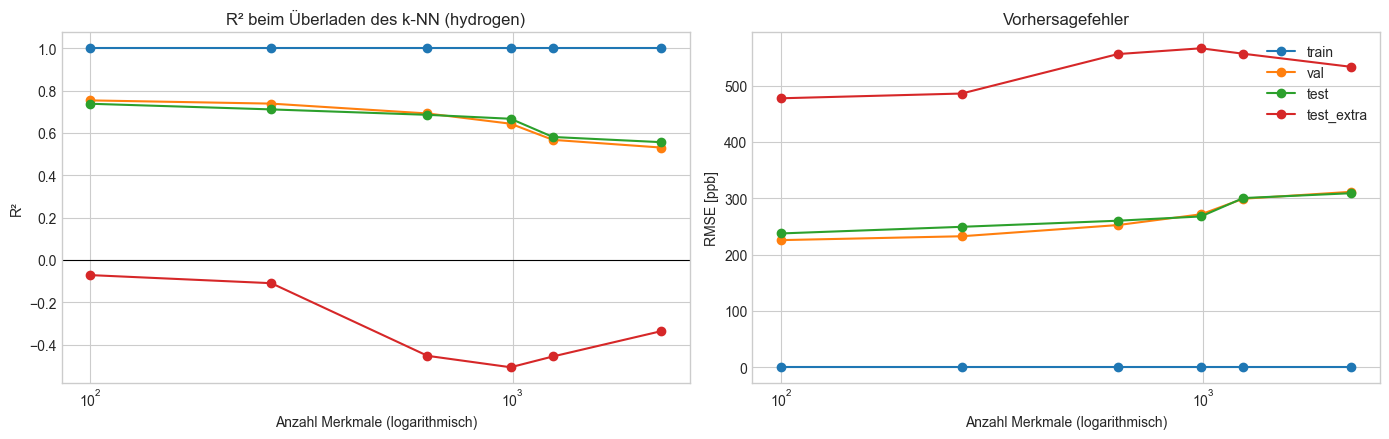

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for split in ("train", "val", "test", "test_extra"):
    subset = [row for row in stage_results if row["Split"] == split]
    axes[0].plot(
        [row["Merkmale"] for row in subset],
        [row["R2"] for row in subset],
        marker="o",
        label=split,
    )
    axes[1].plot(
        [row["Merkmale"] for row in subset],
        [row["RMSE"] for row in subset],
        marker="o",
        label=split,
    )
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Anzahl Merkmale (logarithmisch)")
axes[0].set(title=f"R² beim Überladen des k-NN ({GAS})", ylabel="R²")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[1].set(title="Vorhersagefehler", ylabel="RMSE [ppb]")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Die Abstände verlieren Kontrast

Stufe,Merkmale,Mittlerer nächster Abstand,Mittlerer fernster Abstand,Relativer Kontrast
ALA,100,4.322,28.575,0.844
+ Phasendynamik,268,9.388,43.774,0.780
+ Rohsignal,628,9.953,72.093,0.858
+ Ableitung,988,28.226,77.746,0.629
+ Spektrum,1244,32.261,86.371,0.620
+ 1000 irrelevante,2244,54.748,97.427,0.432


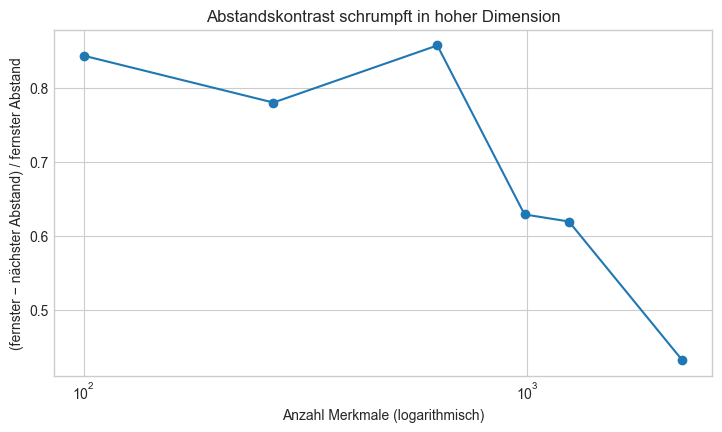

In [7]:
distance_rows = []
for stage_name, _ in stage_definitions:
    scaled = stage_scaled[stage_name]
    query = scaled["val"][:100]
    reference = scaled["train"][:300]
    squared = (
        np.sum(query ** 2, axis=1)[:, None]
        + np.sum(reference ** 2, axis=1)[None, :]
        - 2 * query @ reference.T
    )
    distances = np.sqrt(np.maximum(squared, 0))
    nearest = distances.min(axis=1)
    farthest = distances.max(axis=1)
    distance_rows.append({
        "Stufe": stage_name,
        "Merkmale": scaled["train"].shape[1],
        "Mittlerer nächster Abstand": nearest.mean(),
        "Mittlerer fernster Abstand": farthest.mean(),
        "Relativer Kontrast": np.mean((farthest - nearest) / farthest),
    })

show_table(distance_rows, list(distance_rows[0]))
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(
    [row["Merkmale"] for row in distance_rows],
    [row["Relativer Kontrast"] for row in distance_rows],
    marker="o",
)
ax.set_xscale("log")
ax.set(
    xlabel="Anzahl Merkmale (logarithmisch)",
    ylabel="(fernster − nächster Abstand) / fernster Abstand",
    title="Abstandskontrast schrumpft in hoher Dimension",
)
plt.show()

## 5. Scatterplot: kompakt gegen vollständig überladen

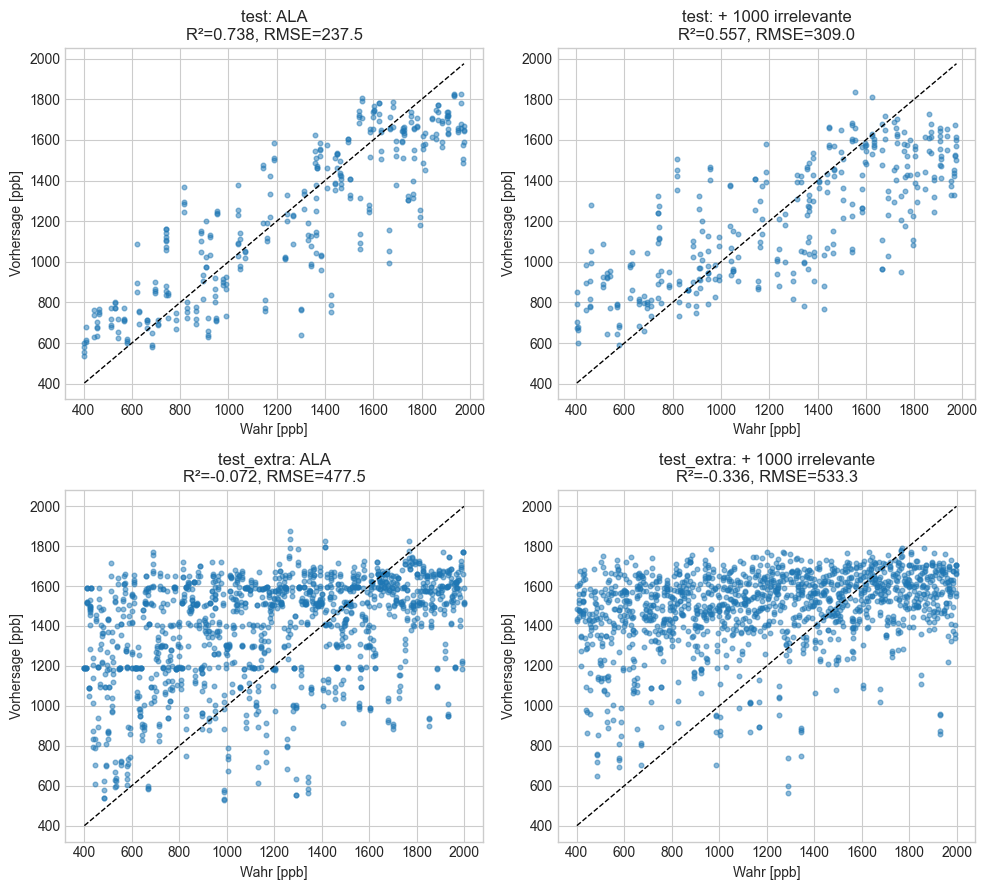

In [8]:
comparison_stages = ("ALA", "+ 1000 irrelevante")
comparison_splits = ("test", "test_extra")
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for row, split in enumerate(comparison_splits):
    truth = splits[split]["targets"][GAS].astype(float)
    for column, stage_name in enumerate(comparison_stages):
        prediction = stage_models[stage_name].predict(
            stage_scaled[stage_name][split]
        )
        score = regression_metrics(truth, prediction)
        lower = min(float(truth.min()), float(prediction.min()))
        upper = max(float(truth.max()), float(prediction.max()))
        ax = axes[row, column]
        ax.scatter(truth, prediction, s=11, alpha=0.5)
        ax.plot([lower, upper], [lower, upper], "k--", linewidth=1)
        ax.set(
            xlabel="Wahr [ppb]", ylabel="Vorhersage [ppb]",
            title=(
                f"{split}: {stage_name}\n"
                f"R²={score['R2']:.3f}, RMSE={score['RMSE']:.1f}"
            ),
        )
plt.tight_layout()
plt.show()

## Schlussfolgerung

Das Trainings-R² bleibt bei einem distanzgewichteten k-NN perfekt, weil
jede Trainingszeile ihr eigener nächster Nachbar ist. Validation und
Test können trotzdem schlechter werden:

- zusätzliche Dimensionen verdünnen die informative Nachbarschaft,
- irrelevante Merkmale tragen nach Standardisierung genauso zum Abstand
  bei wie sinnvolle Merkmale,
- nächster und fernster Nachbar werden relativ ähnlicher.

Die 1.000 Kontrollmerkmale sind ein bewusstes Experiment. In echten
Projekten entsprechen ihnen beispielsweise unselektierte Spektralkanäle,
redundante Fensterstatistiken oder beliebige Sensorableitungen. Die
richtige Konsequenz ist nicht „nie viele Merkmale“, sondern Auswahl,
Regularisierung beziehungsweise Dimensionsreduktion – bewertet auf
vollständig zurückgehaltenen UGM-Gruppen.